# ALIKA Effect on KULA — Analysis v0.2

## Corrected survey definitions

- **Good survey:** score 3, 4, or 5.
- **Bad survey:** score 1 or 2.
- **Total respondents:** good surveys + bad surveys (all valid scores 1–5).
- **Total rating:** sum of valid scores.
- **CSAT:** total rating ÷ total respondents (average score on the 1–5 scale).

## Scope correction

KULA traffic is measured using both `3-1-robot` and `3-1-robot2`, because traffic migrated strongly between these account labels. August 18, 20, and 31 are excluded from normalized period comparisons because their exports stop around 02:20–02:26 and do not represent complete days.

Results show association, not causal proof of ALIKA impact.

In [2]:
import pandas as pd

In [3]:
# June datasets (pre-ALIKA)
df_1_5_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788146480 (1-5 june).csv', low_memory=False)
df_6_10_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788146837 (6-10 june).csv', low_memory=False)
df_11_15_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788148372 (11-15 june).csv', low_memory=False)
df_16_20_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788149085 (16-20 june).csv', low_memory=False)
df_21_25_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788149522 (21-25 june).csv', low_memory=False)
df_26_30_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788150625 (26-30 june).csv', low_memory=False)

# August datasets (ALIKA live). Some exports overlap; duplicates are removed later by conversation id.
df_1_5_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788145507 (1-5 aug).csv', low_memory=False)
df_6_10_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788145209 (6-10 aug).csv', low_memory=False)
df_11_14_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788144961 (11-14 aug).csv', low_memory=False)
df_13_15_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787219325 (13-15 aug).csv', low_memory=False)
df_16_18_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787025549 (16-18 aug).csv', low_memory=False)
df_19_20_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787219503 (19-20 aug).csv', low_memory=False)
df_21_26_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788144629 (21-26 aug).csv', low_memory=False)
df_27_31_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788141789 (27-31 aug).csv', low_memory=False)

In [4]:
# Combine exports, then remove overlapping-export duplicates by conversation id.
data_june = pd.concat(
    [df_1_5_june, df_6_10_june, df_11_15_june, df_16_20_june, df_21_25_june, df_26_30_june],
    ignore_index=True,
).drop_duplicates(subset='id')

data_august = pd.concat(
    [df_1_5_aug, df_6_10_aug, df_11_14_aug, df_13_15_aug, df_16_18_aug, df_19_20_aug, df_21_26_aug, df_27_31_aug],
    ignore_index=True,
).drop_duplicates(subset='id')

print(f'Unique June conversations: {len(data_june):,}')
print(f'Unique August conversations: {len(data_august):,}')

Unique June conversations: 351,236
Unique August conversations: 336,720


In [5]:
# Corrected KULA scope: both account labels belong to the same KULA traffic pool.
KULA_ACCOUNTS = ['3-1-robot', '3-1-robot2']

def prepare_period(frame, period):
    result = frame.loc[frame['currentAccount'].isin(KULA_ACCOUNTS)].copy()
    result['period'] = period
    result['score_num'] = pd.to_numeric(result['score'], errors='coerce')
    result['rated'] = result['score_num'].between(1, 5)
    result['good_survey'] = result['score_num'].isin([3, 4, 5])
    result['bad_survey'] = result['score_num'].isin([1, 2])
    result['from_alika'] = result['changeFlag'].astype('string').str.contains('Alika', case=False, na=False)
    result['datetime'] = pd.to_datetime(result['createTime'], errors='coerce')
    result['date'] = result['datetime'].dt.date
    return result

data_june_clean = prepare_period(data_june, 'June (pre-ALIKA)')
data_august_clean = prepare_period(data_august, 'August (ALIKA live)')

# Detect complete August dates from the full export. A complete date reaches hour 23.
august_last_timestamp = data_august.assign(
    datetime=pd.to_datetime(data_august['createTime'], errors='coerce')
).groupby(pd.to_datetime(data_august['createTime'], errors='coerce').dt.date)['datetime'].max()
complete_august_dates = august_last_timestamp.loc[august_last_timestamp.dt.hour.ge(23)].index
incomplete_august_dates = august_last_timestamp.index.difference(complete_august_dates)
data_august_complete = data_august_clean.loc[data_august_clean['date'].isin(complete_august_dates)].copy()

print(f'KULA June conversations (both accounts): {len(data_june_clean):,}')
print(f'KULA August conversations (all exported dates): {len(data_august_clean):,}')
print(f'KULA August conversations (complete dates): {len(data_august_complete):,}')
print(f'Incomplete August dates excluded from normalized comparison: {list(incomplete_august_dates)}')

KULA June conversations (both accounts): 198,542
KULA August conversations (all exported dates): 183,765
KULA August conversations (complete dates): 182,503
Incomplete August dates excluded from normalized comparison: [datetime.date(2026, 8, 18), datetime.date(2026, 8, 20), datetime.date(2026, 8, 31)]


In [6]:
def metric_summary(frame):
    respondents = frame.loc[frame['rated']]
    total_respondents = len(respondents)
    total_rating = respondents['score_num'].sum()
    good_surveys = int(respondents['good_survey'].sum())
    bad_surveys = int(respondents['bad_survey'].sum())

    return pd.Series({
        'conversations': len(frame),
        'unique_users': frame['userId'].nunique(),
        'days': frame['date'].nunique(),
        'conversations_per_day': len(frame) / frame['date'].nunique(),
        'total_respondents': total_respondents,
        'good_surveys_score_3_5': good_surveys,
        'bad_surveys_score_1_2': bad_surveys,
        'good_survey_%': 100 * good_surveys / total_respondents if total_respondents else float('nan'),
        'bad_survey_%': 100 * bad_surveys / total_respondents if total_respondents else float('nan'),
        'survey_response_rate_%': 100 * total_respondents / len(frame) if len(frame) else float('nan'),
        'total_rating_sum': total_rating,
        'CSAT_avg_score': total_rating / total_respondents if total_respondents else float('nan'),
    })

# Fair period comparison: full June against complete August export dates only.
period_summary = pd.concat(
    {
        'June (pre-ALIKA)': metric_summary(data_june_clean),
        'August (ALIKA live, complete dates)': metric_summary(data_august_complete),
    },
    axis=1,
).round(3)

# Formula integrity check: every valid respondent must be good or bad, never both.
assert (data_june_clean.loc[data_june_clean['rated'], ['good_survey', 'bad_survey']].sum(axis=1) == 1).all()
assert (data_august_complete.loc[data_august_complete['rated'], ['good_survey', 'bad_survey']].sum(axis=1) == 1).all()
period_summary

,June (pre-ALIKA),"August (ALIKA live, complete dates)"
conversations,198542.000,182503.000
unique_users,143060.000,134099.000
days,30.000,28.000
conversations_per_day,6618.067,6517.964
total_respondents,2103.000,1451.000
good_surveys_score_3_5,1222.000,882.000
bad_surveys_score_1_2,881.000,569.000
good_survey_%,58.107,60.786
bad_survey_%,41.893,39.214
survey_response_rate_%,1.059,0.795


In [7]:
# Absolute and relative changes under corrected v0.2 definitions.
comparison = pd.DataFrame({
    'June (pre-ALIKA)': period_summary['June (pre-ALIKA)'],
    'August (ALIKA live, complete dates)': period_summary['August (ALIKA live, complete dates)'],
})
comparison['absolute_change'] = (
    comparison['August (ALIKA live, complete dates)'] - comparison['June (pre-ALIKA)']
)
comparison['relative_change_%'] = (
    100 * comparison['absolute_change'] / comparison['June (pre-ALIKA)']
)
comparison.round(3)

,June (pre-ALIKA),"August (ALIKA live, complete dates)",absolute_change,relative_change_%
conversations,198542.000,182503.000,-16039.000,-8.078
unique_users,143060.000,134099.000,-8961.000,-6.264
days,30.000,28.000,-2.000,-6.667
conversations_per_day,6618.067,6517.964,-100.103,-1.513
total_respondents,2103.000,1451.000,-652.000,-31.003
good_surveys_score_3_5,1222.000,882.000,-340.000,-27.823
bad_surveys_score_1_2,881.000,569.000,-312.000,-35.414
good_survey_%,58.107,60.786,2.679,4.610
bad_survey_%,41.893,39.214,-2.679,-6.395
survey_response_rate_%,1.059,0.795,-0.264,-24.929


In [8]:
# Significance tests compare valid survey respondents only.
# Welch test evaluates CSAT average score; chi-square evaluates good/bad survey composition.
# These tests show association, not causality.
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind

june_rated = data_june_clean.loc[data_june_clean['rated']]
august_rated = data_august_complete.loc[data_august_complete['rated']]

test_rows = []
welch = ttest_ind(june_rated['score_num'], august_rated['score_num'], equal_var=False)
test_rows.append({
    'metric': 'CSAT average score',
    'June': june_rated['score_num'].mean(),
    'August': august_rated['score_num'].mean(),
    'difference_pp_or_score': august_rated['score_num'].mean() - june_rated['score_num'].mean(),
    'p_value': welch.pvalue,
})

for column, label in [('good_survey', 'Good survey rate (3-5)'), ('bad_survey', 'Bad survey rate (1-2)')]:
    table = np.array([
        [june_rated[column].sum(), (~june_rated[column]).sum()],
        [august_rated[column].sum(), (~august_rated[column]).sum()],
    ])
    p_value = chi2_contingency(table, correction=False).pvalue
    june_rate = 100 * june_rated[column].mean()
    august_rate = 100 * august_rated[column].mean()
    test_rows.append({
        'metric': label,
        'June': june_rate,
        'August': august_rate,
        'difference_pp_or_score': august_rate - june_rate,
        'p_value': p_value,
    })

significance_tests = pd.DataFrame(test_rows).set_index('metric')
significance_tests['statistically_significant_at_0.05'] = significance_tests['p_value'].lt(0.05)
significance_tests.round(4)

,June,August,difference_pp_or_score,p_value,statistically_significant_at_0.05
metric,,,,,
CSAT average score,3.2378,3.3570,0.1192,0.0622,False
Good survey rate (3-5),58.1075,60.7857,2.6782,0.1103,False
Bad survey rate (1-2),41.8925,39.2143,-2.6782,0.1103,False


In [9]:
# Direct ALIKA-marked subgroup inside complete August dates.
# Low survey counts can make subgroup estimates unstable.
alika_route_summary = data_august_complete.groupby('from_alika', observed=True).apply(
    metric_summary,
    include_groups=False,
).rename(index={False: 'Not marked from ALIKA', True: 'Marked from ALIKA'}).round(3)

route_counts = pd.DataFrame({
    'conversations': data_august_complete['from_alika'].value_counts(),
    'total_respondents': data_august_complete.groupby('from_alika')['rated'].sum(),
}).rename(index={False: 'Not marked from ALIKA', True: 'Marked from ALIKA'})

route_counts.join(alika_route_summary.drop(columns=['conversations', 'total_respondents']))

,conversations,total_respondents,unique_users,days,conversations_per_day,good_surveys_score_3_5,bad_surveys_score_1_2,good_survey_%,bad_survey_%,survey_response_rate_%,total_rating_sum,CSAT_avg_score
from_alika,,,,,,,,,,,,
Not marked from ALIKA,181731,1449,133559.0,28.0,6490.393,881.0,568.0,60.801,39.199,0.797,4867.0,3.359
Marked from ALIKA,772,2,713.0,23.0,33.565,1.0,1.0,50.000,50.000,0.259,4.0,2.000


In [10]:
# Validate transfer labels in corrected KULA scope.
auto_transfer_distribution = data_august_complete['autoTransferType'].fillna(
    'No automatic transfer'
).value_counts(dropna=False)
print(auto_transfer_distribution.to_string())

# Broader August export context: shows where automatic transfers are recorded.
all_accounts_auto_transfer = data_august.loc[data_august['autoTransferType'].notna(), [
    'currentAccount', 'autoTransferType', 'changeFlag'
]].value_counts().rename('conversations').reset_index()
all_accounts_auto_transfer.head(20)

autoTransferType
No automatic transfer    182503


,currentAccount,autoTransferType,changeFlag,conversations
0,3-1-4047,2.机器人判断自动转人工,4.从Alika中途跳转,1


In [11]:
# Rating distributions among all valid respondents.
rating_distribution = pd.concat([
    june_rated['score_num'].value_counts(normalize=True).mul(100).rename('June (pre-ALIKA)'),
    august_rated['score_num'].value_counts(normalize=True).mul(100).rename('August (complete dates)'),
], axis=1).sort_index().round(2)
rating_distribution.index.name = 'score'
rating_distribution

,June (pre-ALIKA),August (complete dates)
score,,
1.0,38.18,35.49
2.0,3.71,3.72
3.0,3.38,3.10
4.0,5.61,4.96
5.0,49.12,52.72


In [12]:
# v0.2 conclusion: corrected KULA scope, complete-date normalization, corrected survey formulas.
volume_change = 100 * (
    period_summary.loc['conversations_per_day', 'August (ALIKA live, complete dates)'] /
    period_summary.loc['conversations_per_day', 'June (pre-ALIKA)'] - 1
)
good_change = significance_tests.loc['Good survey rate (3-5)', 'difference_pp_or_score']
bad_change = significance_tests.loc['Bad survey rate (1-2)', 'difference_pp_or_score']
csat_change = significance_tests.loc['CSAT average score', 'difference_pp_or_score']
quality_p = significance_tests['p_value']
alika_complete = data_august_complete.loc[data_august_complete['from_alika']]
alika_respondents = int(alika_complete['rated'].sum())

print('ALIKA Effect on KULA — Analysis v0.2')
print(f'Combined KULA volume: {volume_change:+.1f}% conversations/day in complete August dates versus June.')
print(f'Good survey (scores 3-5): {good_change:+.2f} percentage points; p={quality_p.loc["Good survey rate (3-5)"]:.3f}.')
print(f'Bad survey (scores 1-2): {bad_change:+.2f} percentage points; p={quality_p.loc["Bad survey rate (1-2)"]:.3f}.')
print(f'CSAT average score: {period_summary.loc["CSAT_avg_score", "June (pre-ALIKA)"]:.3f} to {period_summary.loc["CSAT_avg_score", "August (ALIKA live, complete dates)"]:.3f} ({csat_change:+.3f}); p={quality_p.loc["CSAT average score"]:.3f}.')
print(f'Survey response rate: {period_summary.loc["survey_response_rate_%", "June (pre-ALIKA)"]:.2f}% to {period_summary.loc["survey_response_rate_%", "August (ALIKA live, complete dates)"]:.2f}%.')
print(f'ALIKA-marked complete-date conversations: {len(alika_complete):,}; respondents: {alika_respondents}.')
print('\nInterpretation: combined KULA traffic stayed approximately flat. Survey outcomes improved directionally, but evidence does not reach the 0.05 significance threshold. ALIKA causality remains unproven because exposure marking and survey response are limited.')

ALIKA Effect on KULA — Analysis v0.2
Combined KULA volume: -1.5% conversations/day in complete August dates versus June.
Good survey (scores 3-5): +2.68 percentage points; p=0.110.
Bad survey (scores 1-2): -2.68 percentage points; p=0.110.
CSAT average score: 3.238 to 3.357 (+0.119); p=0.062.
Survey response rate: 1.06% to 0.80%.
ALIKA-marked complete-date conversations: 772; respondents: 2.

Interpretation: combined KULA traffic stayed approximately flat. Survey outcomes improved directionally, but evidence does not reach the 0.05 significance threshold. ALIKA causality remains unproven because exposure marking and survey response are limited.


In [ ]:
# Incoming KULA complaint volume analysis using all complaint rows, not just unique users.
connected_user_summary = pd.DataFrame({
    'June (before ALIKA)': {
        'Total incoming complaints': len(data_june_clean),
        'Average complaints/day': data_june_clean.groupby('date').size().mean(),
        'Total unique users': data_june_clean['userId'].nunique(),
    },
    'August (complete dates)': {
        'Total incoming complaints': len(data_august_complete),
        'Average complaints/day': data_august_complete.groupby('date').size().mean(),
        'Total unique users': data_august_complete['userId'].nunique(),
    },
})
connected_user_summary['Change'] = (
    connected_user_summary['August (complete dates)'] - connected_user_summary['June (before ALIKA)']
)
connected_user_summary['Change_%'] = (
    100 * connected_user_summary['Change'] / connected_user_summary['June (before ALIKA)']
)
connected_user_summary.round(2)

,June (before ALIKA),August (complete dates),Change,Change_%
Unique connected users,143060.00,134099.00,-8961.00,-6.26
KULA conversations,198542.00,182503.00,-16039.00,-8.08
Average unique users/day,5744.43,5694.29,-50.15,-0.87
Average conversations/day,6618.07,6517.96,-100.10,-1.51
Conversations per user,1.39,1.36,-0.03,-1.94


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

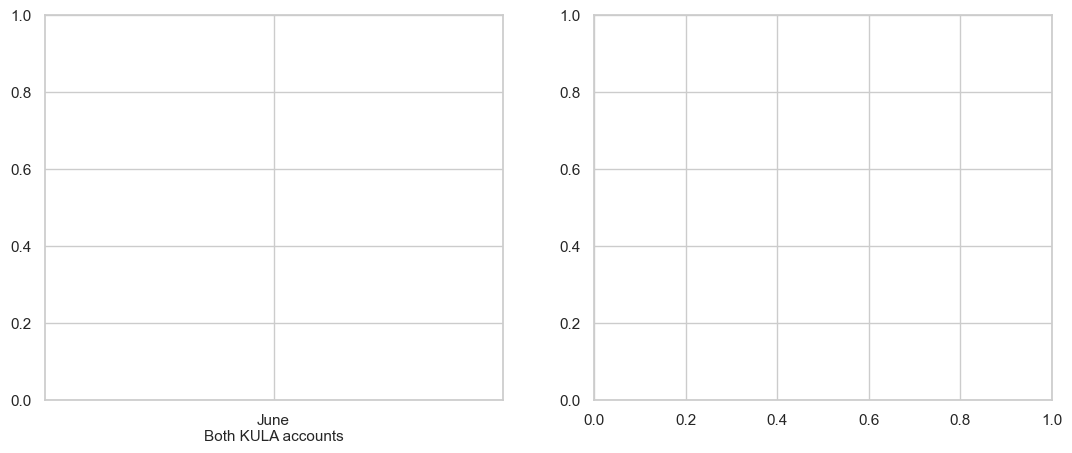

In [ ]:
# Visualize total incoming KULA complaints using all complaint rows, not unique users.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
period_colors = ['#4C78A8', '#F58518']

# Monthly totals should sum all incoming complaint rows in the KULA scope.
monthly_complaints = [
    len(data_june_clean),
    len(data_august_complete),
]
labels = ['June\nBoth KULA accounts', 'August\nComplete dates']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(labels, monthly_complaints, color=period_colors, width=0.62)
axes[0].bar_label(bars, labels=[f'{value:,.0f}' for value in monthly_complaints], padding=4, fontweight='bold')
axes[0].set_title('Total Incoming KULA Complaints')
axes[0].set_ylabel('Complaints')
axes[0].set_ylim(0, max(monthly_complaints) * 1.15)

# Daily plots should count all complaint rows per day before plotting.
june_daily = data_june_clean.groupby('date').size().reset_index(name='complaints')
august_daily = data_august_complete.groupby('date').size().reset_index(name='complaints')

june_daily['day_of_month'] = pd.to_datetime(june_daily['date']).dt.day
august_daily['day_of_month'] = pd.to_datetime(august_daily['date']).dt.day

axes[1].plot(
    june_daily['day_of_month'],
    june_daily['complaints'],
    marker='o',
    markersize=3,
    label='June: both accounts',
    color=period_colors[0],
)
axes[1].plot(
    august_daily['day_of_month'],
    august_daily['complaints'],
    marker='o',
    markersize=3,
    label='August: complete dates',
    color=period_colors[1],
)
axes[1].set_title('Daily KULA Incoming Complaints')
axes[1].set_xlabel('Day of month')
axes[1].set_ylabel('Complaints/day')
axes[1].legend(frameon=False)

fig.suptitle('KULA Complaint Volume — Analysis v0.2', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

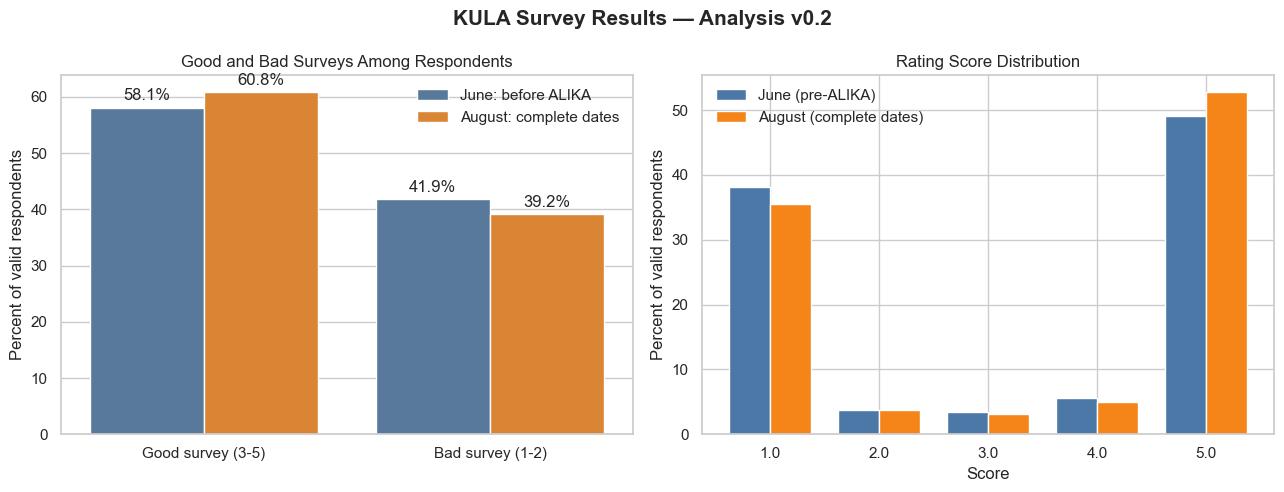

In [ ]:
# Visualize corrected survey definitions and score distribution.
quality_plot = pd.DataFrame({
    'Period': ['June: before ALIKA', 'August: complete dates'] * 2,
    'Metric': ['Good survey (3-5)'] * 2 + ['Bad survey (1-2)'] * 2,
    'Percent': [
        100 * june_rated['good_survey'].mean(),
        100 * august_rated['good_survey'].mean(),
        100 * june_rated['bad_survey'].mean(),
        100 * august_rated['bad_survey'].mean(),
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=quality_plot, x='Metric', y='Percent', hue='Period', palette=period_colors, ax=axes[0])
axes[0].set_title('Good and Bad Surveys Among Respondents')
axes[0].set_xlabel('')
axes[0].set_ylabel('Percent of valid respondents')
axes[0].legend(title='', frameon=False)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3)

rating_distribution.plot(kind='bar', ax=axes[1], color=period_colors, width=0.75)
axes[1].set_title('Rating Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Percent of valid respondents')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(frameon=False)

fig.suptitle('KULA Survey Results — Analysis v0.2', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()